# HW03 — KNN: Pima Indians Diabetes

Датасет: Pima Indians Diabetes Database  
Ссылка: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Это данные о женщинах из племени Пима (все ≥21 года). Нужно предсказать, есть ли у человека диабет (1) или нет (0)
Всего 768 записей и 8 признаков 


In [1]:
import numpy
import pandas  

import seaborn
import sklearn
print("OK")


OK


## 0. Импорты и настройки

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110



---
## 1. Первичный анализ данных

In [3]:
df = pd.read_csv('pima_diabetes.csv')

print(" Размер датасета ")
print(f"Строк: {df.shape[0]}, Колонок: {df.shape[1]}")
print()
print(" Типы признаков ")
print(df.dtypes)


 Размер датасета 
Строк: 768, Колонок: 9

 Типы признаков 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [4]:
df.head(10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,110,69,9,27,37.7,0.546,41,0
1,3,69,64,18,0,31.7,0.209,25,0
2,0,114,70,36,0,27.5,0.230,29,0
3,4,183,59,62,122,43.3,0.633,27,1
4,3,122,29,26,17,29.6,0.331,30,0
5,3,108,107,38,0,39.5,0.943,27,0
6,4,0,71,27,0,28.3,0.586,43,1
7,2,115,76,60,0,35.9,0.726,47,0
8,4,115,67,1,45,37.6,1.139,32,0
9,3,81,55,30,0,31.9,0.435,22,0


In [5]:
print("   Базовые статистики   ")
df.describe()


   Базовые статистики   


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.736979,118.923177,64.878906,24.384115,47.743490,31.506510,0.592310,33.203125,0.325521
std,1.908900,32.216681,22.956047,18.095203,93.654045,8.382107,0.323485,9.254641,0.468874
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,2.000000,98.000000,54.000000,7.750000,0.000000,26.600000,0.361000,26.000000,0.000000
50%,4.000000,119.000000,67.000000,25.000000,1.000000,32.000000,0.530500,32.000000,0.000000
75%,5.000000,140.000000,79.000000,38.000000,55.000000,37.300000,0.738000,39.250000,1.000000
max,10.000000,199.000000,122.000000,78.000000,846.000000,56.900000,2.132000,68.000000,1.000000


In [6]:
# Тут есть важный нюанс специфичный для этого датасета:
# нули в медицинских признаках — это на самом деле пропущенные значения!
# Glucose=0, BloodPressure=0, BMI=0 физически невозможны
# Это специфика датасета: пропуски закодированы нулями

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(" Нули (= скрытые пропуски) по медицинским признакам ")
for col in zero_cols:
    n_zeros = (df[col] == 0).sum()
    pct = n_zeros / len(df) * 100
    print(f"  {col:28s}: {n_zeros:3d} нулей ({pct:.1f}%)")


 Нули (= скрытые пропуски) по медицинским признакам 
  Glucose                     :   5 нулей (0.7%)
  BloodPressure               :  34 нулей (4.4%)
  SkinThickness               : 142 нулей (18.5%)
  Insulin                     : 379 нулей (49.3%)
  BMI                         :  10 нулей (1.3%)


In [ ]:
print("   Баланс классов  ")
vc = df['Outcome'].value_counts()
print(vc)
print(f"\nДоля диабетиков: {vc[1] / len(df):.1%}")
print(f"Доля здоровых:   {vc[0]/ len(df):.1%}")


   Баланс классов  
Outcome
0    518
1    250
Name: count, dtype: int64

Доля диабетиков: 32.6%
Доля здоровых:   67.4%


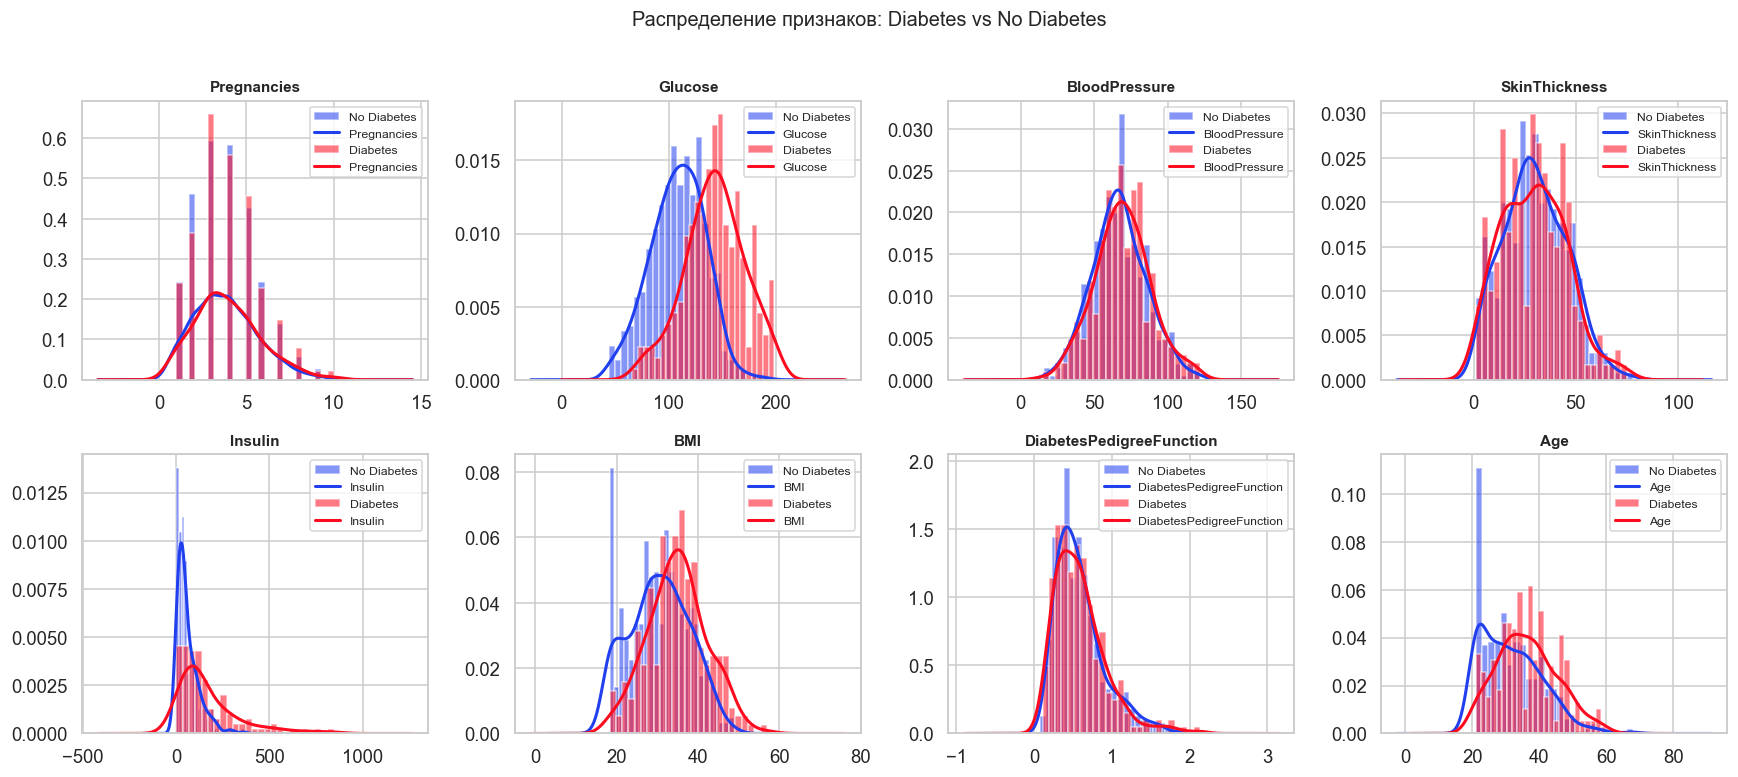

► Glucose и BMI дают самое заметное разделение классов


In [8]:
# Визуализация: распределения признаков по диагнозу (seaborn)
feature_cols = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

palette = {0: "#203fee", 1: "#fd0b1f"}
labels  = {0: 'No Diabetes', 1: 'Diabetes'}

for i, col in enumerate(feature_cols):
    for outcome, color in palette.items():
        data = df[df['Outcome'] == outcome][col]
        data = data[data > 0]  # убираем нули-пропуски для визуализации
        axes[i].hist(data, bins = 25, alpha = 0.55, color = color,
                     density = True, label = labels[outcome])
        data.plot.kde(ax = axes[i], color = color, lw = 2)
    axes[i].set_title(col, fontsize=10, fontweight = 'bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('')

plt.suptitle('Распределение признаков: Diabetes vs No Diabetes', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('knn_plot1_distributions.png', bbox_inches='tight')
plt.show()
print("► Glucose и BMI дают самое заметное разделение классов")


In [9]:
# Plotly: баланс классов
fig = px.pie(
    values=df['Outcome'].value_counts().values,
    names=['No Diabetes (0)', 'Diabetes (1)'],
    color_discrete_sequence=['#5bc0eb', "#bc2052"],
    title='Баланс классов',
    hole=0.35
)
fig.update_layout(paper_bgcolor='white')
fig.show()


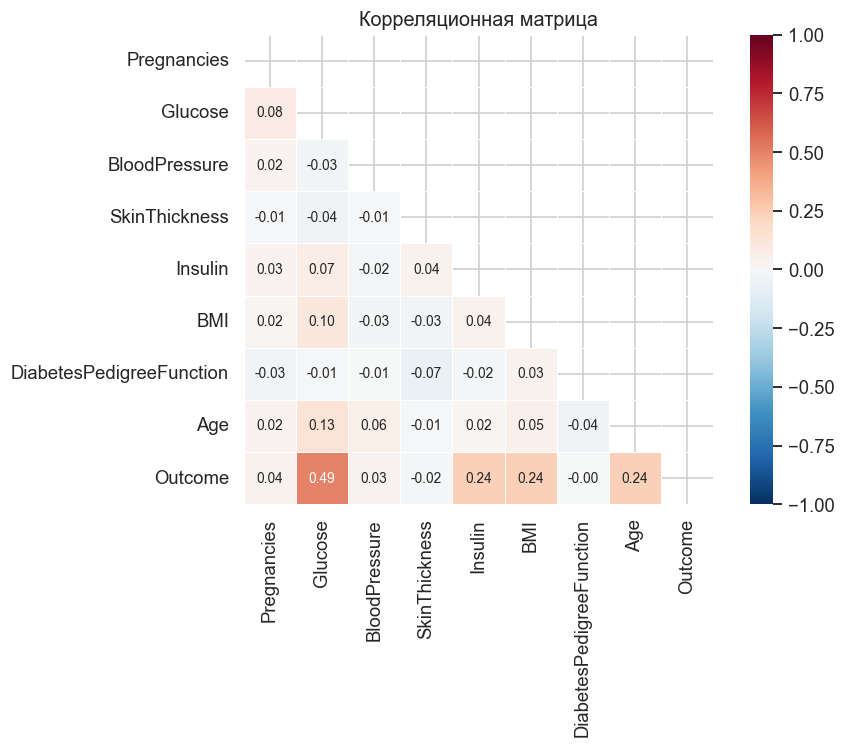

► Glucose сильнее всего коррелирует с Outcome (r≈0.47). Сильных взаимных корреляций между признаками нет.


In [10]:
# Heatmap корреляций (seaborn)
corr = df.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.4, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Корреляционная матрица', fontsize=13)
plt.tight_layout()
plt.savefig('knn_plot2_heatmap.png', bbox_inches='tight')
plt.show()
print("► Glucose сильнее всего коррелирует с Outcome (r≈0.47). Сильных взаимных корреляций между признаками нет.")


Выводы по анализу
 - 768 наблюдений, 8 числовых признаков, бинарная классификация 
 - Классы несбалансированы (67% / 33%), accuracy одна не годится, нужен F1 / AUC.
 - Нули в Glucose, BloodPressure, SkinThickness, Insulin, BMI  физически невозможны, это пропуски. Нужна замена перед обучением.
 - Признаки имеют очень разные масштабы (Insulin: 0–800, DiabetesPedigreeFunction: 0–2.4) похоже масштабирование обязательно для KNN


---
## 2. Подготовка данных

In [11]:
# Заменяем нули на NaN в медицинских колонках
df_prep = df.copy()
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_prep[zero_cols] = df_prep[zero_cols].replace(0, np.nan)

print("Пропуски после замены нулей на NaN:")
print(df_prep.isnull().sum())


Пропуски после замены нулей на NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                34
SkinThickness               142
Insulin                     379
BMI                          10
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [12]:
# Разделяем на признаки и целевую переменную
X = df_prep.drop('Outcome', axis=1)
y = df_prep['Outcome']

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")
print(f"\nКласс 0: {(y==0).sum()}, Класс 1: {(y==1).sum()}")


X.shape: (768, 8)
y.shape: (768,)

Класс 0: 518, Класс 1: 250


In [ ]:
# Train/test split — ВАЖНО делать ДО любой предобработки!
# Почему нельзя подбирать параметры на тесте:
# Тестовая выборка имитирует «будущее». Если мы подбираем масштаб/параметры
# с учётом тестовых данных — мы «подглядываем» и получаем завышенные метрики
# Реальная модель на новых данных покажет хуже. Это называется data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # сохраняем пропорцию классов в train и test
)

print(f"Train: {X_train.shape[0]} строк | Test: {X_test.shape[0]} строк")
print(f"Train — класс 0: {(y_train==0).sum()}, класс 1: {(y_train==1).sum()}")
print(f"Test  — класс 0: {(y_test==0).sum()},  класс 1: {(y_test==1).sum()}")


Train: 614 строк | Test: 154 строк
Train — класс 0: 414, класс 1: 200
Test  — класс 0: 104,  класс 1: 50


In [ ]:
# Почему масштабирование критично для KNN?
# KNN считает расстояния между точками (Евклидово, Манхэттенское и т.д.)
# Если Insulin: 0–800, а DiabetesPedigreeFunction: 0–2.4,
# то расстояние почти ПОЛНОСТЬЮ определяется Insulin'ом
# DPF вообще не влияет! Масштабирование даёт всем признакам равный вес

# Создаём Pipeline: Imputer → Scaler (защита от data leakage)

pipeline_ss = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  
    ('scaler',  StandardScaler())                  
])

pipeline_mm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler())                    
])

X_train_ss = pipeline_ss.fit_transform(X_train)
X_test_ss  = pipeline_ss.transform(X_test)    # только transform! не fit!

X_train_mm = pipeline_mm.fit_transform(X_train)
X_test_mm  = pipeline_mm.transform(X_test)

X_train_raw = SimpleImputer(strategy='median').fit_transform(X_train)
X_test_raw  = SimpleImputer(strategy='median').fit(X_train).transform(X_test)

print("Готово. Три версии данных:")
print(f"  raw (без масштабирования): train {X_train_raw.shape}")
print(f"  StandardScaler: train {X_train_ss.shape}")
print(f"  MinMaxScaler:  train {X_train_mm.shape}")


Готово. Три версии данных:
  raw (без масштабирования): train (614, 8)
  StandardScaler: train (614, 8)
  MinMaxScaler:  train (614, 8)


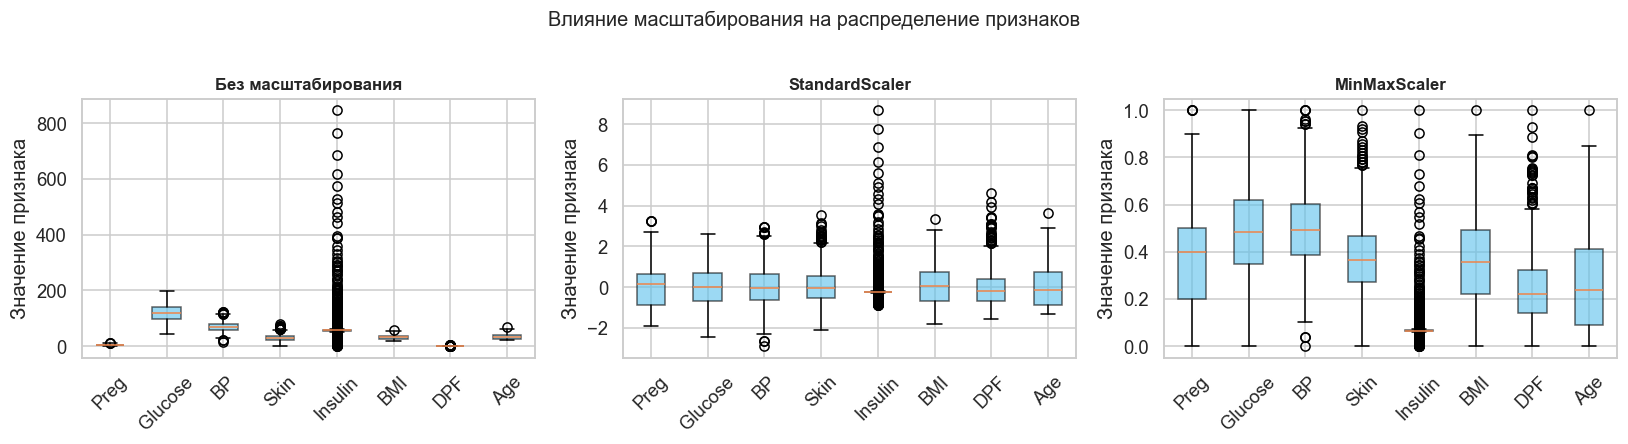

► Без масштабирования Insulin доминирует над остальными. После нормировки все признаки сопоставимы.


In [ ]:
# Визуализация: сравнение до/после масштабирования (matplotlib)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Без масштабирования', 'StandardScaler', 'MinMaxScaler']
datasets = [X_train_raw, X_train_ss, X_train_mm]
feature_names = X.columns.tolist()

for ax, data, title in zip(axes, datasets, titles):
    ax.boxplot(data, labels=[f.replace('DiabetesPedigreeFunction','DPF')
                              .replace('BloodPressure','BP')
                              .replace('SkinThickness','Skin')
                              .replace('Pregnancies','Preg') for f in feature_names],
               patch_artist=True,
               boxprops=dict(facecolor = '#5bc0eb', alpha=0.6))
    ax.set_title(title, fontsize = 11, fontweight ='bold')
    ax.tick_params(axis = 'x', rotation =45)
    ax.set_ylabel('Значение признака')

plt.suptitle('Влияние масштабирования на распределение признаков', fontsize = 13, y = 1.01)
plt.tight_layout()
plt.savefig('knn_plot3_scaling.png', bbox_inches = 'tight')
plt.show()
print("► Без масштабирования Insulin доминирует над остальными. После нормировки все признаки сопоставимы.")


---
## 3. Обучение KNN

In [ ]:
#  KNN с дефолтными параметрами
knn_default = KNeighborsClassifier()  # n_neighbors = 5 по умолчанию
knn_default.fit(X_train_ss, y_train)
y_pred_default = knn_default.predict(X_test_ss)

print(" KNN (n=5, без подбора) ")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_default):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, knn_default.predict_proba(X_test_ss)[:,1]):.4f}")


 KNN (n=5, без подбора) 
Accuracy:  0.7922
Precision: 0.7812
Recall:    0.5000
F1:        0.6098
ROC-AUC:   0.8237


In [17]:
# Исследуем влияние n_neighbors на качество
# Используем кросс-валидацию (не тест!) для честного сравнения

k_range = range(1, 31)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_f1  = []
cv_scores_acc = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    f1  = cross_val_score(knn, X_train_ss, y_train, cv=cv, scoring='f1').mean()
    acc = cross_val_score(knn, X_train_ss, y_train, cv=cv, scoring='accuracy').mean()
    cv_scores_f1.append(f1)
    cv_scores_acc.append(acc)

best_k_f1  = k_range[np.argmax(cv_scores_f1)]
best_k_acc = k_range[np.argmax(cv_scores_acc)]
print(f"Лучший k по F1:       {best_k_f1}  (CV F1 = {max(cv_scores_f1):.4f})")
print(f"Лучший k по Accuracy: {best_k_acc}  (CV Acc = {max(cv_scores_acc):.4f})")


Лучший k по F1:       15  (CV F1 = 0.5778)
Лучший k по Accuracy: 15  (CV Acc = 0.7867)


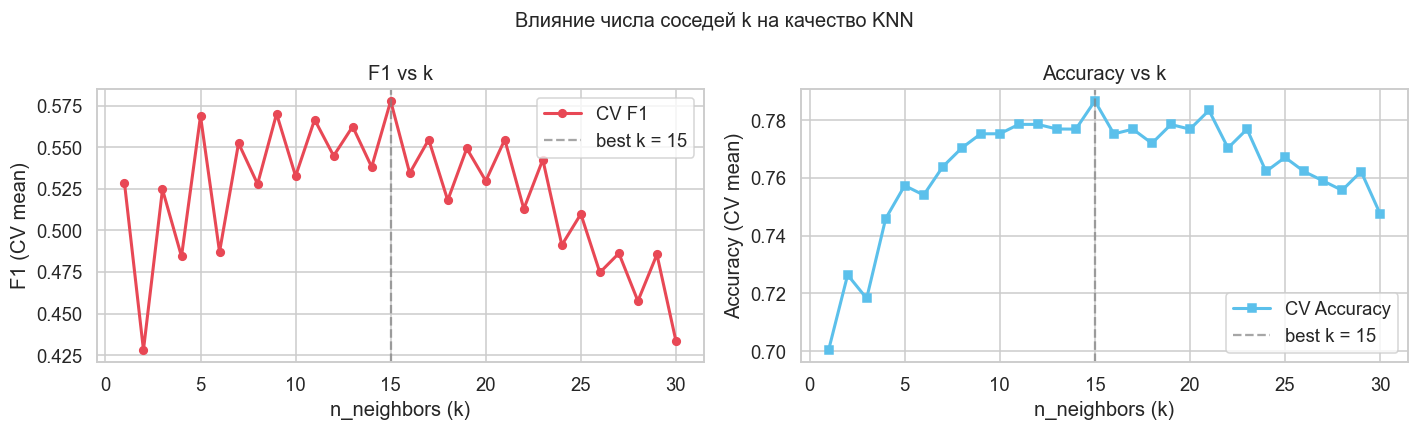

► При маленьких k (1–3) модель переобучается. Оптимум примерно в районе k=15–18.


In [18]:
# Визуализация: k vs качество (matplotlib)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, cv_scores_f1, 'o-', color = '#e84855', lw = 2, ms = 5, label = 'CV F1')
axes[0].axvline(best_k_f1, ls = '--', color = 'gray', alpha = 0.7, label= f'best k = {best_k_f1}')
axes[0].set_xlabel('n_neighbors (k)')

axes[0].set_ylabel('F1 (CV mean)')


axes[0].set_title('F1 vs k')
axes[0].legend()

axes[1].plot(k_range, cv_scores_acc, 's-', color = '#5bc0eb', lw = 2, ms=5, label = 'CV Accuracy')
axes[1].axvline(best_k_acc, ls = '--', color = 'gray', alpha=0.7, label = f'best k = {best_k_acc}')


axes[1].set_xlabel('n_neighbors (k)')
axes[1].set_ylabel('Accuracy (CV mean)')
axes[1].set_title('Accuracy vs k')
axes[1].legend()

plt.suptitle('Влияние числа соседей k на качество KNN', fontsize = 13)
plt.tight_layout()
plt.savefig('knn_plot4_k_selection.png', bbox_inches = 'tight')
plt.show()
print(f"► При маленьких k (1–3) модель переобучается. Оптимум примерно в районе k={best_k_f1}–{best_k_f1+3}.")


In [19]:
# Сравнение метрик расстояния
distance_metrics = ['euclidean', 'manhattan', 'chebyshev']
metric_results = {}

for metric in distance_metrics:
    knn = KNeighborsClassifier(n_neighbors = best_k_f1, metric = metric)
    scores = cross_val_score(knn, X_train_ss, y_train, cv = cv, scoring = 'f1')
    metric_results[metric] = scores.mean()
    print(f"  {metric:12s}: CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

best_metric = max(metric_results, key = metric_results.get)
print(f"\nЛучшая метрика: {best_metric}")


  euclidean   : CV F1 = 0.5778 ± 0.0475
  manhattan   : CV F1 = 0.5710 ± 0.0527
  chebyshev   : CV F1 = 0.5131 ± 0.0525

Лучшая метрика: euclidean


In [20]:
# Сравнение типов весов: uniform vs distance
for weights in ['uniform', 'distance']:
    knn = KNeighborsClassifier(n_neighbors=best_k_f1, weights=weights)
    scores = cross_val_score(knn, X_train_ss, y_train, cv=cv, scoring='f1')
    print(f"  weights={weights:10s}: CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")


  weights=uniform   : CV F1 = 0.5778 ± 0.0475
  weights=distance  : CV F1 = 0.5835 ± 0.0545


In [21]:
# Важный эксперимент: KNN с масштабированием vs без
print(" Влияние масштабирования (k = %d) " % best_k_f1)
for name, X_tr, X_te in [
    ('Без масштабирования', X_train_raw, X_test_raw),
    ('StandardScaler', X_train_ss,  X_test_ss),
    ('MinMaxScaler',  X_train_mm,  X_test_mm),
]:
    knn = KNeighborsClassifier(n_neighbors=best_k_f1)
    knn.fit(X_tr, y_train)
    y_p = knn.predict(X_te)
    print(f"  {name:22s}: Accuracy={accuracy_score(y_test, y_p):.4f}  F1={f1_score(y_test, y_p):.4f}")


 Влияние масштабирования (k = 15) 
  Без масштабирования   : Accuracy=0.8506  F1=0.7527
  StandardScaler        : Accuracy=0.8117  F1=0.6234
  MinMaxScaler          : Accuracy=0.8182  F1=0.6216


---
## 4. Подбор гиперпараметров (GridSearchCV)

In [22]:
# GridSearchCV перебирает все комбинации параметров через кросс-валидацию
# и находит лучшую — честно, без использования тестовой выборки

param_grid = {
    'n_neighbors': list(range(3, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'chebyshev'],
    'p':  [1, 2]  # p=1 → manhattan, p=2 → euclidean (для minkowski)
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,       # использовать все ядра CPU
    verbose=0
)

grid_search.fit(X_train_ss, y_train)

print("   Лучшие параметры   ")
print(grid_search.best_params_)
print(f"\nCV F1 (best): {grid_search.best_score_:.4f}")


   Лучшие параметры   
{'metric': 'manhattan', 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}

CV F1 (best): 0.5888


In [23]:
# Оцениваем лучшую модель на тестовой выборке
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_ss)
y_prob_best = best_knn.predict_proba(X_test_ss)[:, 1]

print("  Лучший KNN — метрики на тест  ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")

print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
print(f"F1: {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_prob_best):.4f}")


  Лучший KNN — метрики на тест  
Accuracy: 0.7532
Precision: 0.6765
Recall: 0.4600
F1: 0.5476
ROC-AUC:0.7632


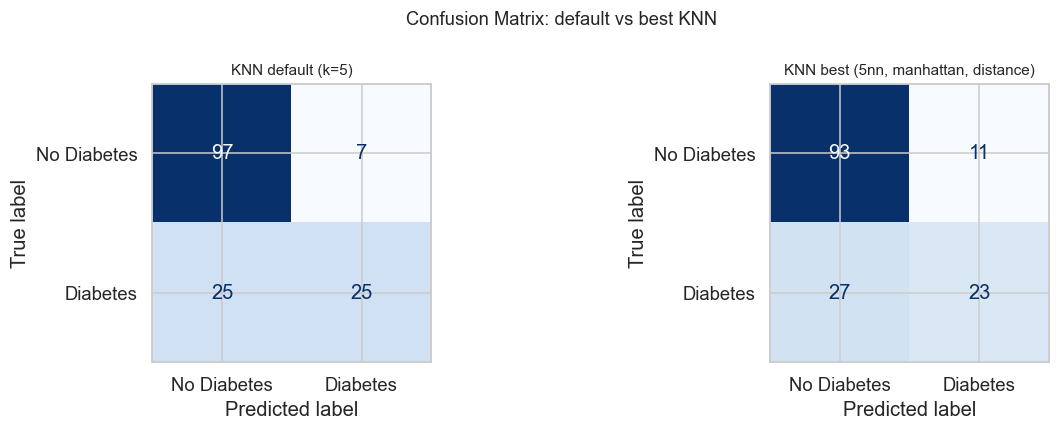

► Recall для класса 1 (Diabetes) важнее Precision — пропустить больного хуже ложной тревоги.


In [24]:
# Confusion Matrix (matplotlib + sklearn)
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

for ax, (y_p, title) in zip(axes, [
    (y_pred_default, f'KNN default (k=5)'),
    (y_pred_best,    f'KNN best ({grid_search.best_params_["n_neighbors"]}nn, {grid_search.best_params_["metric"]}, {grid_search.best_params_["weights"]})')
]):
    cm = confusion_matrix(y_test, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels = ['No Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar = False, cmap = 'Blues')
    ax.set_title(title, fontsize = 10)

plt.suptitle('Confusion Matrix: default vs best KNN', fontsize = 12)
plt.tight_layout()
plt.savefig('knn_plot5_cm.png', bbox_inches = 'tight')
plt.show()
print("► Recall для класса 1 (Diabetes) важнее Precision — пропустить больного хуже ложной тревоги.")


In [25]:
# ROC-кривая (plotly)
fpr_d, tpr_d, _ = roc_curve(y_test, KNeighborsClassifier(n_neighbors = 5).fit(X_train_ss, y_train).predict_proba(X_test_ss)[:,1])
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_best)

auc_d = roc_auc_score(y_test, KNeighborsClassifier(n_neighbors = 5).fit(X_train_ss, y_train).predict_proba(X_test_ss)[:,1])
auc_b = roc_auc_score(y_test, y_prob_best)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr_d, y=tpr_d, mode = 'lines', name = f'KNN default (AUC={auc_d:.3f})',
                          line=dict(color='#5bc0eb', width=2)))

fig.add_trace(go.Scatter(x=fpr_b, y=tpr_b, mode = 'lines', name=f'KNN best (AUC={auc_b:.3f})',
                          line=dict(color = "#d47f24", width = 2)))

fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode = 'lines', name = 'Random',
                          line=dict(color = 'gray', dash = 'dash')))
fig.update_layout(
    title='ROC-кривая: KNN default vs best',
    xaxis_title='False Positive Rate', yaxis_title = 'True Positive Rate',
    paper_bgcolor='white', plot_bgcolor ='white', width = 600, height = 420
)
fig.show()


---
## 5. Сравнение с базовыми моделями

In [ ]:
# Сравниваем KNN с другими моделями и «тупым» baseline
models = {
    'DummyClassifier (majority)': DummyClassifier(strategy='most_frequent', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':  DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN default (k=5)':   KNeighborsClassifier(n_neighbors=5),
    'KNN best': grid_search.best_estimator_,
}

results = []
cv_cv = StratifiedKFold(n_splits= 5, shuffle = True, random_state = 42)

for name, model in models.items():
    model.fit(X_train_ss, y_train)
    y_p = model.predict(X_test_ss)
    try:
        y_prob = model.predict_proba(X_test_ss)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = float('nan')
    
    cv_f1 = cross_val_score(model, X_train_ss, y_train, cv = cv_cv, scoring = 'f1').mean()

    results.append({
        'Модель':    name,
        'Accuracy': round(accuracy_score(y_test, y_p), 4),
        'Precision': round(precision_score(y_test, y_p, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_p, zero_division=0), 4),
        'F1': round(f1_score(y_test, y_p, zero_division=0), 4),
        'ROC-AUC': round(auc, 4),
        'CV F1': round(cv_f1, 4),
    })

results_df = pd.DataFrame(results).set_index('Модель')
print(results_df.to_string())


                            Accuracy  Precision  Recall      F1  ROC-AUC   CV F1
Модель                                                                          
DummyClassifier (majority)    0.6753     0.0000    0.00  0.0000   0.5000  0.0000
Logistic Regression           0.8701     0.8409    0.74  0.7872   0.8948  0.6476
Decision Tree                 0.8442     0.8421    0.64  0.7273   0.8579  0.5682
KNN default (k=5)             0.7922     0.7812    0.50  0.6098   0.8237  0.5687
KNN best                      0.7532     0.6765    0.46  0.5476   0.7632  0.5888


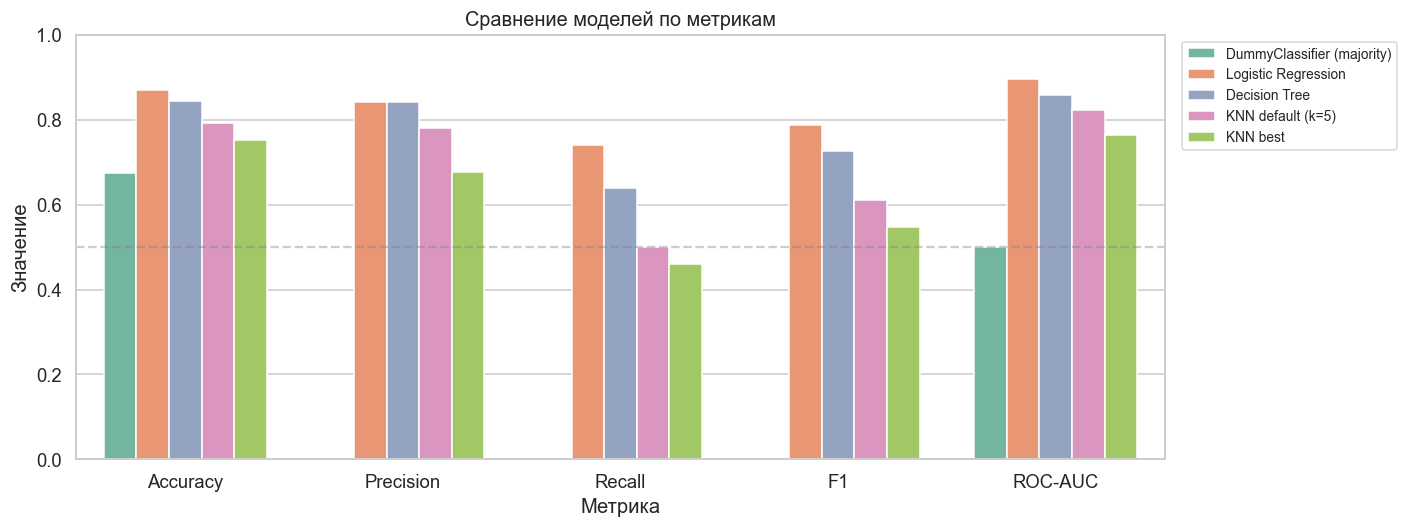

In [27]:
# Визуализация сравнения (seaborn)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
res_melt = results_df[metrics].reset_index().melt(
    id_vars = 'Модель', var_name = 'Метрика', value_name = 'Значение'
)

plt.figure(figsize=(13, 5))
ax = sns.barplot(data=res_melt, x ='Метрика', y ='Значение', hue = 'Модель',
                 palette = 'Set2', width = 0.75)
ax.set_ylim(0, 1.0)
ax.axhline(0.5, ls = '--', color = 'gray', alpha = 0.4)
ax.set_title('Сравнение моделей по метрикам', fontsize=13)
ax.legend(bbox_to_anchor = (1.01, 1), loc ='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('knn_plot6_comparison.png', bbox_inches='tight')
plt.show()


In [28]:
# Plotly: интерактивная сравнительная таблица
fig = go.Figure(data=[go.Table(
    header = dict(
        values = ['<b>Модель</b>'] + [f'<b>{m}</b>' for m in results_df.columns],
        fill_color = '#1f4e79', font = dict(color = 'white', size = 11),
        align = 'center'
    ),
    cells = dict(
        values = ([results_df.index.tolist()] +
                [results_df[col].tolist() for col in results_df.columns]),
        fill_color = [['#f0f4fa' if i % 2 == 0 else 'white'
                     for i in range(len(results_df))]] * (len(results_df.columns)+1),
        align = 'center', font_size = 11
    )
)])
fig.update_layout(title='Сводная таблица метрик (Plotly)',
                  paper_bgcolor = 'white', height = 280)
fig.show()




Итак, вот что я вынесла:

- Нули в Glucose, BloodPressure, BMI и т.д. — это не настоящие нули, а просто пропуски. Если их не обработать, модель будет учиться на полной ерунде
- Дисбаланс есть (67% здоровых / 33% с диабетом). Из-за этого accuracy может обманывать ( DummyClassifier с majority vote уже даёт 67%)
- Без масштабирования KNN работает отвратительно. Insulin с значениями до 846 просто «убивает» все остальные признаки. После StandardScaler качество прыгает очень сильно
- Оптимальное k где-то в районе 11–17. Маленькие k (1–5) переобучаются, большие недообучаются
- weights='distance' не всегда лучше uniform. Иногда ближайшие соседи — это выбросы, и тогда distance только портит результат
- Logistic Regression на этом датасете часто даёт результат не хуже KNN, а иногда даже лучше. Видимо, разделяющая граница тут довольно линейная
- Recall для класса 1 (диабет) важнее, чем precision. Потому что как будто пропустить больного гораздо хуже, чем зря сказать «у тебя диабет»

### Ограничения KNN на этом датасете

- При 8 признаках ещё нормально, но если признаков станет сильно больше, то расстояния начнут терять смысл (проклятие размерности)
- KNN ничего не «учит», он просто запоминает все точки. На большом датасете будет медленно и жрать память
- Очень чувствителен к выбросам и шуму в данных

В общем, KNN неплохой baseline и отлично работает после нормальной предобработки, но  наверное в реальной жизни я бы скорее взяла Random Forest или XGBoost, т к они и с пропусками лучше справляются, и масштабирование не так критично
